In [1]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path
import seaborn as sns

from analysis.utils import fit_rastermap, plot_rastermap_with_rewards_actions

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/glfw/__init__.py:914: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)


In [2]:
def load_intervention_data(df_metadata,
                           intervention_type=None,
                           hinge_1_value=None,
                           seed=None,
                           selection_type=None,
                           selection_threshold=None,
                           variable=None,
                           pca_component_idx=None):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    type_list = to_list(intervention_type)
    hinge_1_value_list = to_list(hinge_1_value)
    seed_list = to_list(seed)
    selection_type_list = to_list(selection_type)
    selection_threshold_list = to_list(selection_threshold)
    variable_list = to_list(variable)
    pca_component_idx_list = to_list(pca_component_idx)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        # Check each criterion
        if type_list is not None and config.get('config_type') not in type_list:
            continue
        if hinge_1_value_list is not None and config.get(
                'config_hinge_1_value') not in hinge_1_value_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue
        if selection_type_list is not None and config.get(
                'config_selection_type') not in selection_type_list:
            continue
        if selection_threshold_list is not None and config.get(
                'config_selection_threshold') not in selection_threshold_list:
            continue
        if variable_list is not None and config.get(
                'config_variable') not in variable_list:
            continue
        if pca_component_idx_list is not None and config.get(
                'config_pca_component_idx') not in pca_component_idx_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in tqdm(filtered_configs):
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


def compute_success(df_data, threshold_angle=0.1, consecutive_steps=100):
    """
    Compute whether the pole is upright (straight) for consecutive_steps time points.
    
    Args:
        df_data: DataFrame with 'observations' column containing state arrays
        threshold_angle: Maximum angle deviation from vertical (in radians) to consider "straight"
        consecutive_steps: Number of consecutive steps required for success
    
    Returns:
        df_data: DataFrame with added 'success' column
    """
    success = []

    for idx in range(len(df_data)):
        observations = np.array(df_data['observations'].iloc[idx])

        # Extract cos and sin of pole angle (dimensions 1 and 2)
        cos_angle = observations[:, 1]
        sin_angle = observations[:, 2]

        # Compute actual angle from cos and sin
        angles = np.arctan2(sin_angle, cos_angle)

        # Check if angle is within threshold (close to 0, which is upright)
        is_straight = np.abs(angles) < threshold_angle

        # Check for consecutive_steps consecutive True values
        episode_success = False
        count = 0
        for straight in is_straight:
            if straight:
                count += 1
                if count >= consecutive_steps:
                    episode_success = True
                    break
            else:
                count = 0

        success.append(episode_success)

    df_data['success'] = np.array(success)
    return df_data

In [11]:
def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


def load_sweep_metadata(sweep_base_dirs):
    """
    Load metadata from all sweep directories.
    
    Args:
        sweep_base_dirs: Path or list of paths to base directories containing sweep results
    
    Returns:
        DataFrame with flattened metadata from all configurations
    """
    # Convert single path to list for uniform handling
    if not isinstance(sweep_base_dirs, list):
        sweep_base_dirs = [sweep_base_dirs]

    all_metadata = []
    for sweep_base_dir in sweep_base_dirs:
        sweep_base_dir = Path(sweep_base_dir)
        for sweep_dir in sweep_base_dir.iterdir():
            if sweep_dir.is_dir():
                metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
                if metadata_path.exists():
                    with open(metadata_path, 'r') as f:
                        metadata = json.load(f)
                        # Flatten the nested metadata dictionary
                        flattened_metadata = flatten_dict(metadata)
                        # Add the directory path
                        flattened_metadata['directory'] = str(sweep_dir)
                        all_metadata.append(flattened_metadata)

    print(f"Found {len(all_metadata)} configurations")

    # Create DataFrame from flattened metadata
    df_metadata = pd.DataFrame(all_metadata)
    return df_metadata


# Loop over all directories in the sweep logs
#sweep_base_dir = Path("logs/191125-latent_intervention_mt30-317M_sweep")
df_metadata = load_sweep_metadata(sweep_base_dirs=[
    "logs/191125-latent_intervention_mt30-317M_sweep",
    "/home/hgf_hmgu/hgf_gib4562/tdmpc2/logs/181125-initial_conditions_mt30-317M_sweep"
])


Found 225 configurations


In [12]:
df_metadata.head()

,config_type,config_location,config_direction,config_hinge_1_value,config_seed,config_pca_component_idx,checkpoint,task,latent_dim,episode_idx,episode_length,total_reward,timestamp,obs_type,directory
0,directional_ablation,encoder_output,"[-0.002914136741310358, 0.029643552377820015, ...",1.91,4,0,ckpts/mt30-317M.pt,mt30,1376,0,500,729.219494,2025-11-19T13:28:58.117985,state,logs/191125-latent_intervention_mt30-317M_swee...
1,directional_ablation,encoder_output,"[-0.0059319306164979935, 0.005642198957502842,...",1.50,1,1,ckpts/mt30-317M.pt,mt30,1376,0,500,798.658816,2025-11-19T11:26:06.645142,state,logs/191125-latent_intervention_mt30-317M_swee...
2,random_direction,encoder_output,NaN,-2.32,4,NaN,ckpts/mt30-317M.pt,mt30,1376,0,500,728.727967,2025-11-19T15:08:17.096987,state,logs/191125-latent_intervention_mt30-317M_swee...
3,directional_ablation,encoder_output,"[-0.005361405201256275, 0.033933788537979126, ...",1.50,3,2,ckpts/mt30-317M.pt,mt30,1376,0,500,726.505990,2025-11-19T12:47:24.661682,state,logs/191125-latent_intervention_mt30-317M_swee...
4,random_direction,encoder_output,NaN,2.32,2,NaN,ckpts/mt30-317M.pt,mt30,1376,0,500,728.488182,2025-11-19T14:49:01.037859,state,logs/191125-latent_intervention_mt30-317M_swee...


In [14]:
df_metadata['config_type'] = df_metadata['config_type'].fillna('baseline')

In [15]:
df_metadata['config_type'].unique()

array(['directional_ablation', 'random_direction', 'baseline'],
      dtype=object)

In [16]:
df_metadata['config_hinge_1_value_degrees'] = np.degrees(
    df_metadata['config_hinge_1_value'])

df_metadata['hinge_str'] = df_metadata['config_hinge_1_value_degrees'].round(
    0).astype(str)

## Directional ablation

In [39]:
df_baseline = df_metadata[df_metadata['config_type'] == 'baseline']
df_baseline['config_pca_component_idx'] = 'no ablation'
df_rd = df_metadata[df_metadata['config_type'] == 'random_direction']
df_rd['config_pca_component_idx'] = 'random direction ablation'
df_pca = df_metadata[df_metadata['config_type'] == 'directional_ablation']

df_direction = pd.concat([df_pca, df_rd, df_baseline])
# df_direction['config_pca_component_idx'] = df_direction[
#     'config_pca_component_idx'].fillna('random')

/scratch/slurm_tmpdir/job_1585912/ipykernel_3454308/168489207.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_baseline['config_pca_component_idx'] = 'no ablation'
/scratch/slurm_tmpdir/job_1585912/ipykernel_3454308/168489207.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rd['config_pca_component_idx'] = 'random direction ablation'


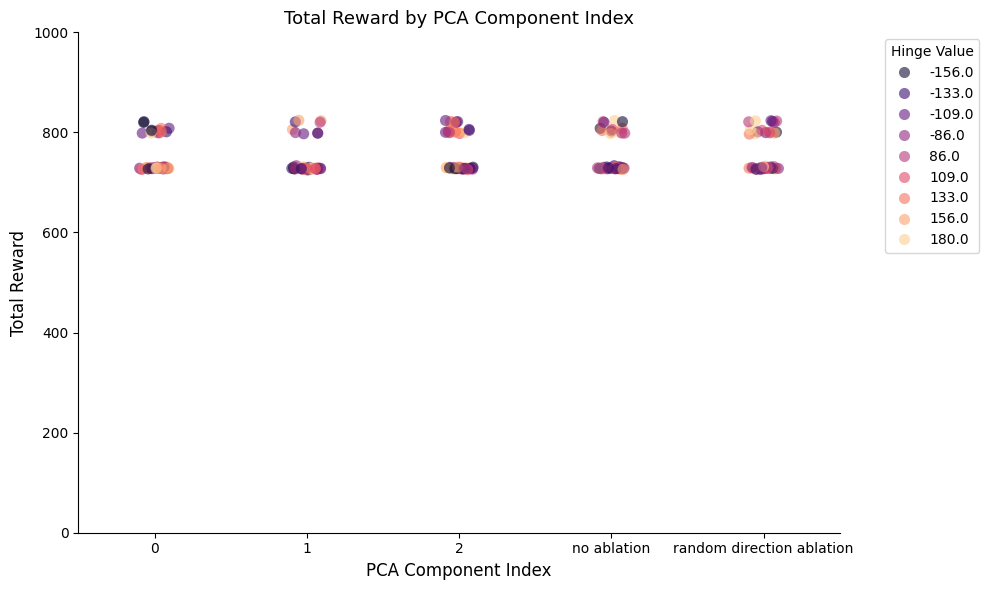

In [ ]:
# # Create a nice scatter plot with jitter, colored by config_hinge_1_value

fig, ax = plt.subplots(figsize=(10, 6))
sns.stripplot(data=df_direction,
              x='config_pca_component_idx',
              y='total_reward',
              hue='hinge_str',
              jitter=True,
              alpha=0.6,
              size=8,
              ax=ax,
              order=sorted(df_direction['config_pca_component_idx'].unique()),
              hue_order=sorted(df_direction['hinge_str'].unique(),
                               key=lambda x: float(x)),
              palette='magma')

ax.set_xlabel('PCA Component Index', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Total Reward by PCA Component Index', fontsize=13)
ax.legend(title='Hinge Value', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.ylim(0, 1000)
plt.tight_layout()
plt.show()

In [32]:
df_pca_data = load_intervention_data(df_metadata,
                                     intervention_type="directional_ablation")
df_rd_data = load_intervention_data(df_metadata,
                                    intervention_type="random_direction")
df_baseline_data = load_intervention_data(df_metadata,
                                          intervention_type="baseline")

df_rd_data['config_pca_component_idx'] = 'random'
df_baseline_data['config_pca_component_idx'] = 'baseline'

df_data = pd.concat([df_pca_data, df_rd_data, df_baseline_data])

df_direction_data = pd.concat([df_pca_data, df_rd_data, df_baseline_data])
df_direction_data = compute_success(df_direction_data, consecutive_steps=100)

Found 135 configurations


100%|██████████| 135/135 [00:00<00:00, 208.35it/s]


Found 45 configurations


100%|██████████| 45/45 [00:00<00:00, 207.99it/s]


Found 45 configurations


100%|██████████| 45/45 [00:00<00:00, 205.19it/s]


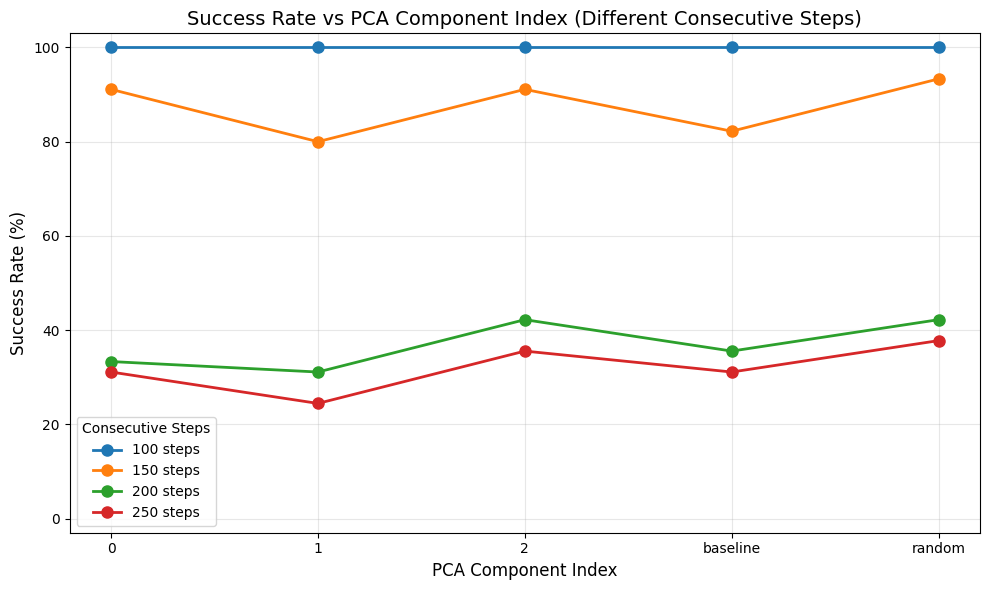

In [45]:
# Define different consecutive_steps values to test
consecutive_steps_values = [100, 150, 200, 250]

# Create a figure for plotting
plt.figure(figsize=(10, 6))

# Compute and plot success rate for each consecutive_steps value
for consecutive_steps in consecutive_steps_values:
    # Compute success for this consecutive_steps value
    df_temp = compute_success(df_direction_data.copy(),
                              consecutive_steps=consecutive_steps)

    # Group by PCA component index and compute mean success rate across seeds
    success_by_pca = df_temp.groupby(
        'config_pca_component_idx')['success'].mean().reset_index()
    success_by_pca.columns = ['pca_component_idx', 'success_rate']

    # Convert success rate to percentage
    success_by_pca['success_percentage'] = success_by_pca['success_rate'] * 100

    # Plot line for this consecutive_steps value
    plt.plot(success_by_pca['pca_component_idx'],
             success_by_pca['success_percentage'],
             marker='o',
             linewidth=2,
             markersize=8,
             label=f'{consecutive_steps} steps')

plt.xlabel('PCA Component Index', fontsize=12)
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('Success Rate vs PCA Component Index (Different Consecutive Steps)',
          fontsize=14)
plt.legend(title='Consecutive Steps', loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-3, 103)
plt.show()

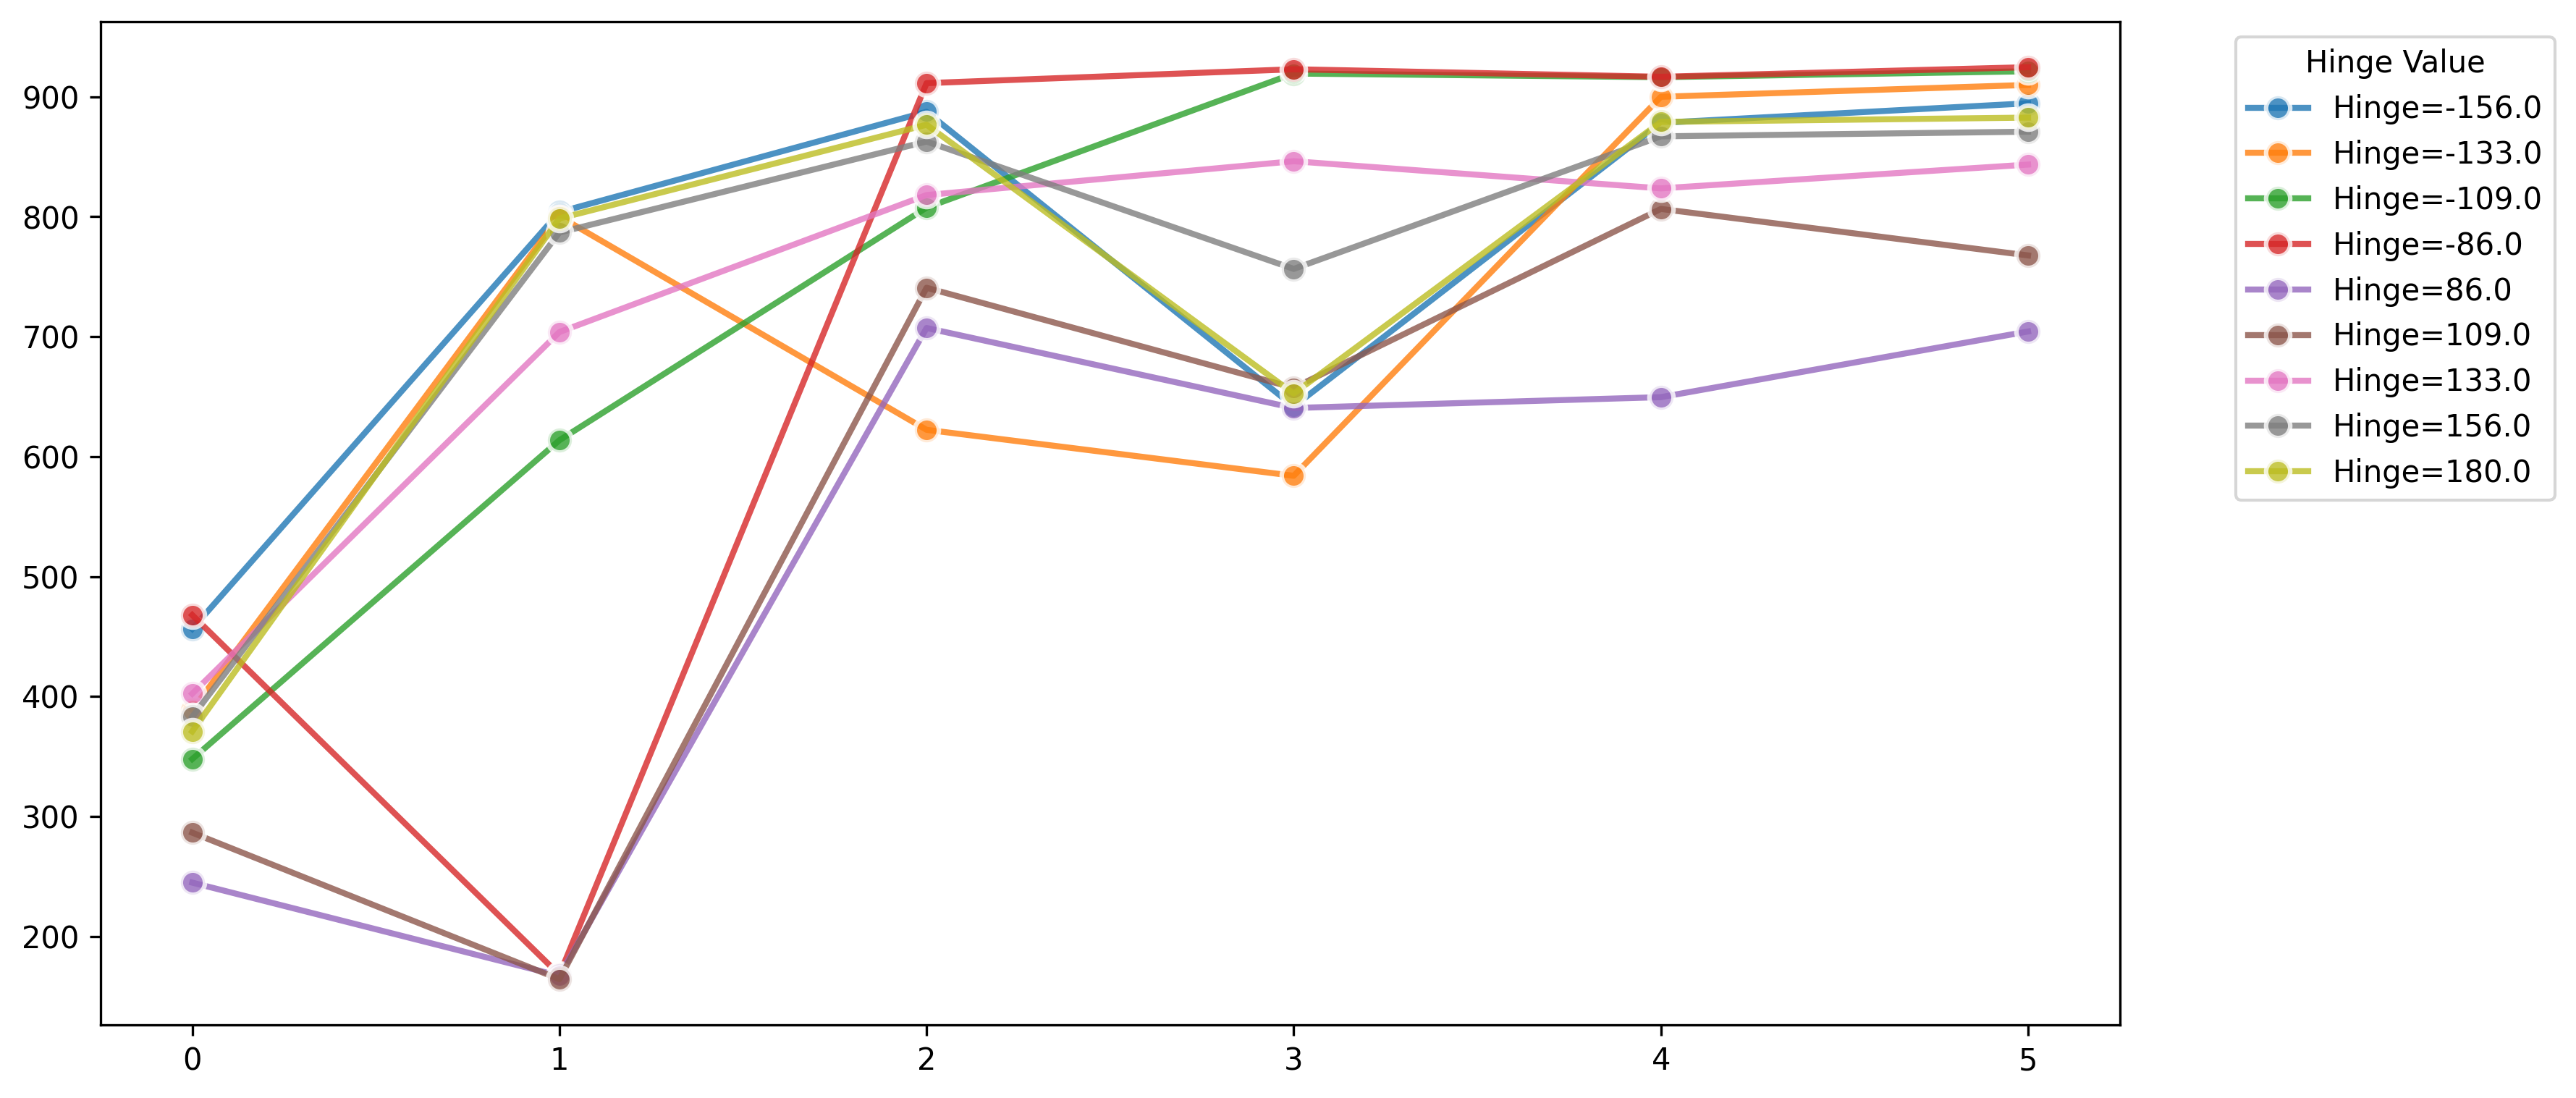

In [137]:
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)

#Calculate mean reward for each hinge value and PCA component
mean_rewards = df_direction.groupby(['config_pca_component_idx', 'hinge_str'
                                    ])['total_reward'].mean().reset_index()

# Get the color palette used for the stripplot
palette = sns.color_palette('tab10',
                            n_colors=len(df_direction['hinge_str'].unique()))
hinge_order = sorted(df_direction['hinge_str'].unique(), key=lambda x: float(x))
color_map = {hinge: palette[i] for i, hinge in enumerate(hinge_order)}

# Plot lines for each hinge value
pca_components = sorted(df_direction['config_pca_component_idx'].unique())
for hinge_val in hinge_order:
    hinge_data = mean_rewards[mean_rewards['hinge_str'] == hinge_val]
    # Create x positions for the line (matching the stripplot positions)
    x_positions = [
        pca_components.index(comp)
        for comp in hinge_data['config_pca_component_idx']
    ]
    ax.plot(x_positions,
            hinge_data['total_reward'],
            color=color_map[hinge_val],
            linewidth=2,
            alpha=0.8,
            marker='o',
            markersize=8,
            markeredgecolor='white',
            markeredgewidth=1.5,
            label=f'Hinge={hinge_val}')

ax.legend(title='Hinge Value', bbox_to_anchor=(1.05, 1), loc='upper left')

## sensitivty of directional scaling ablation

/scratch/slurm_tmpdir/job_1585912/ipykernel_3207672/3772649574.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tick_labels)


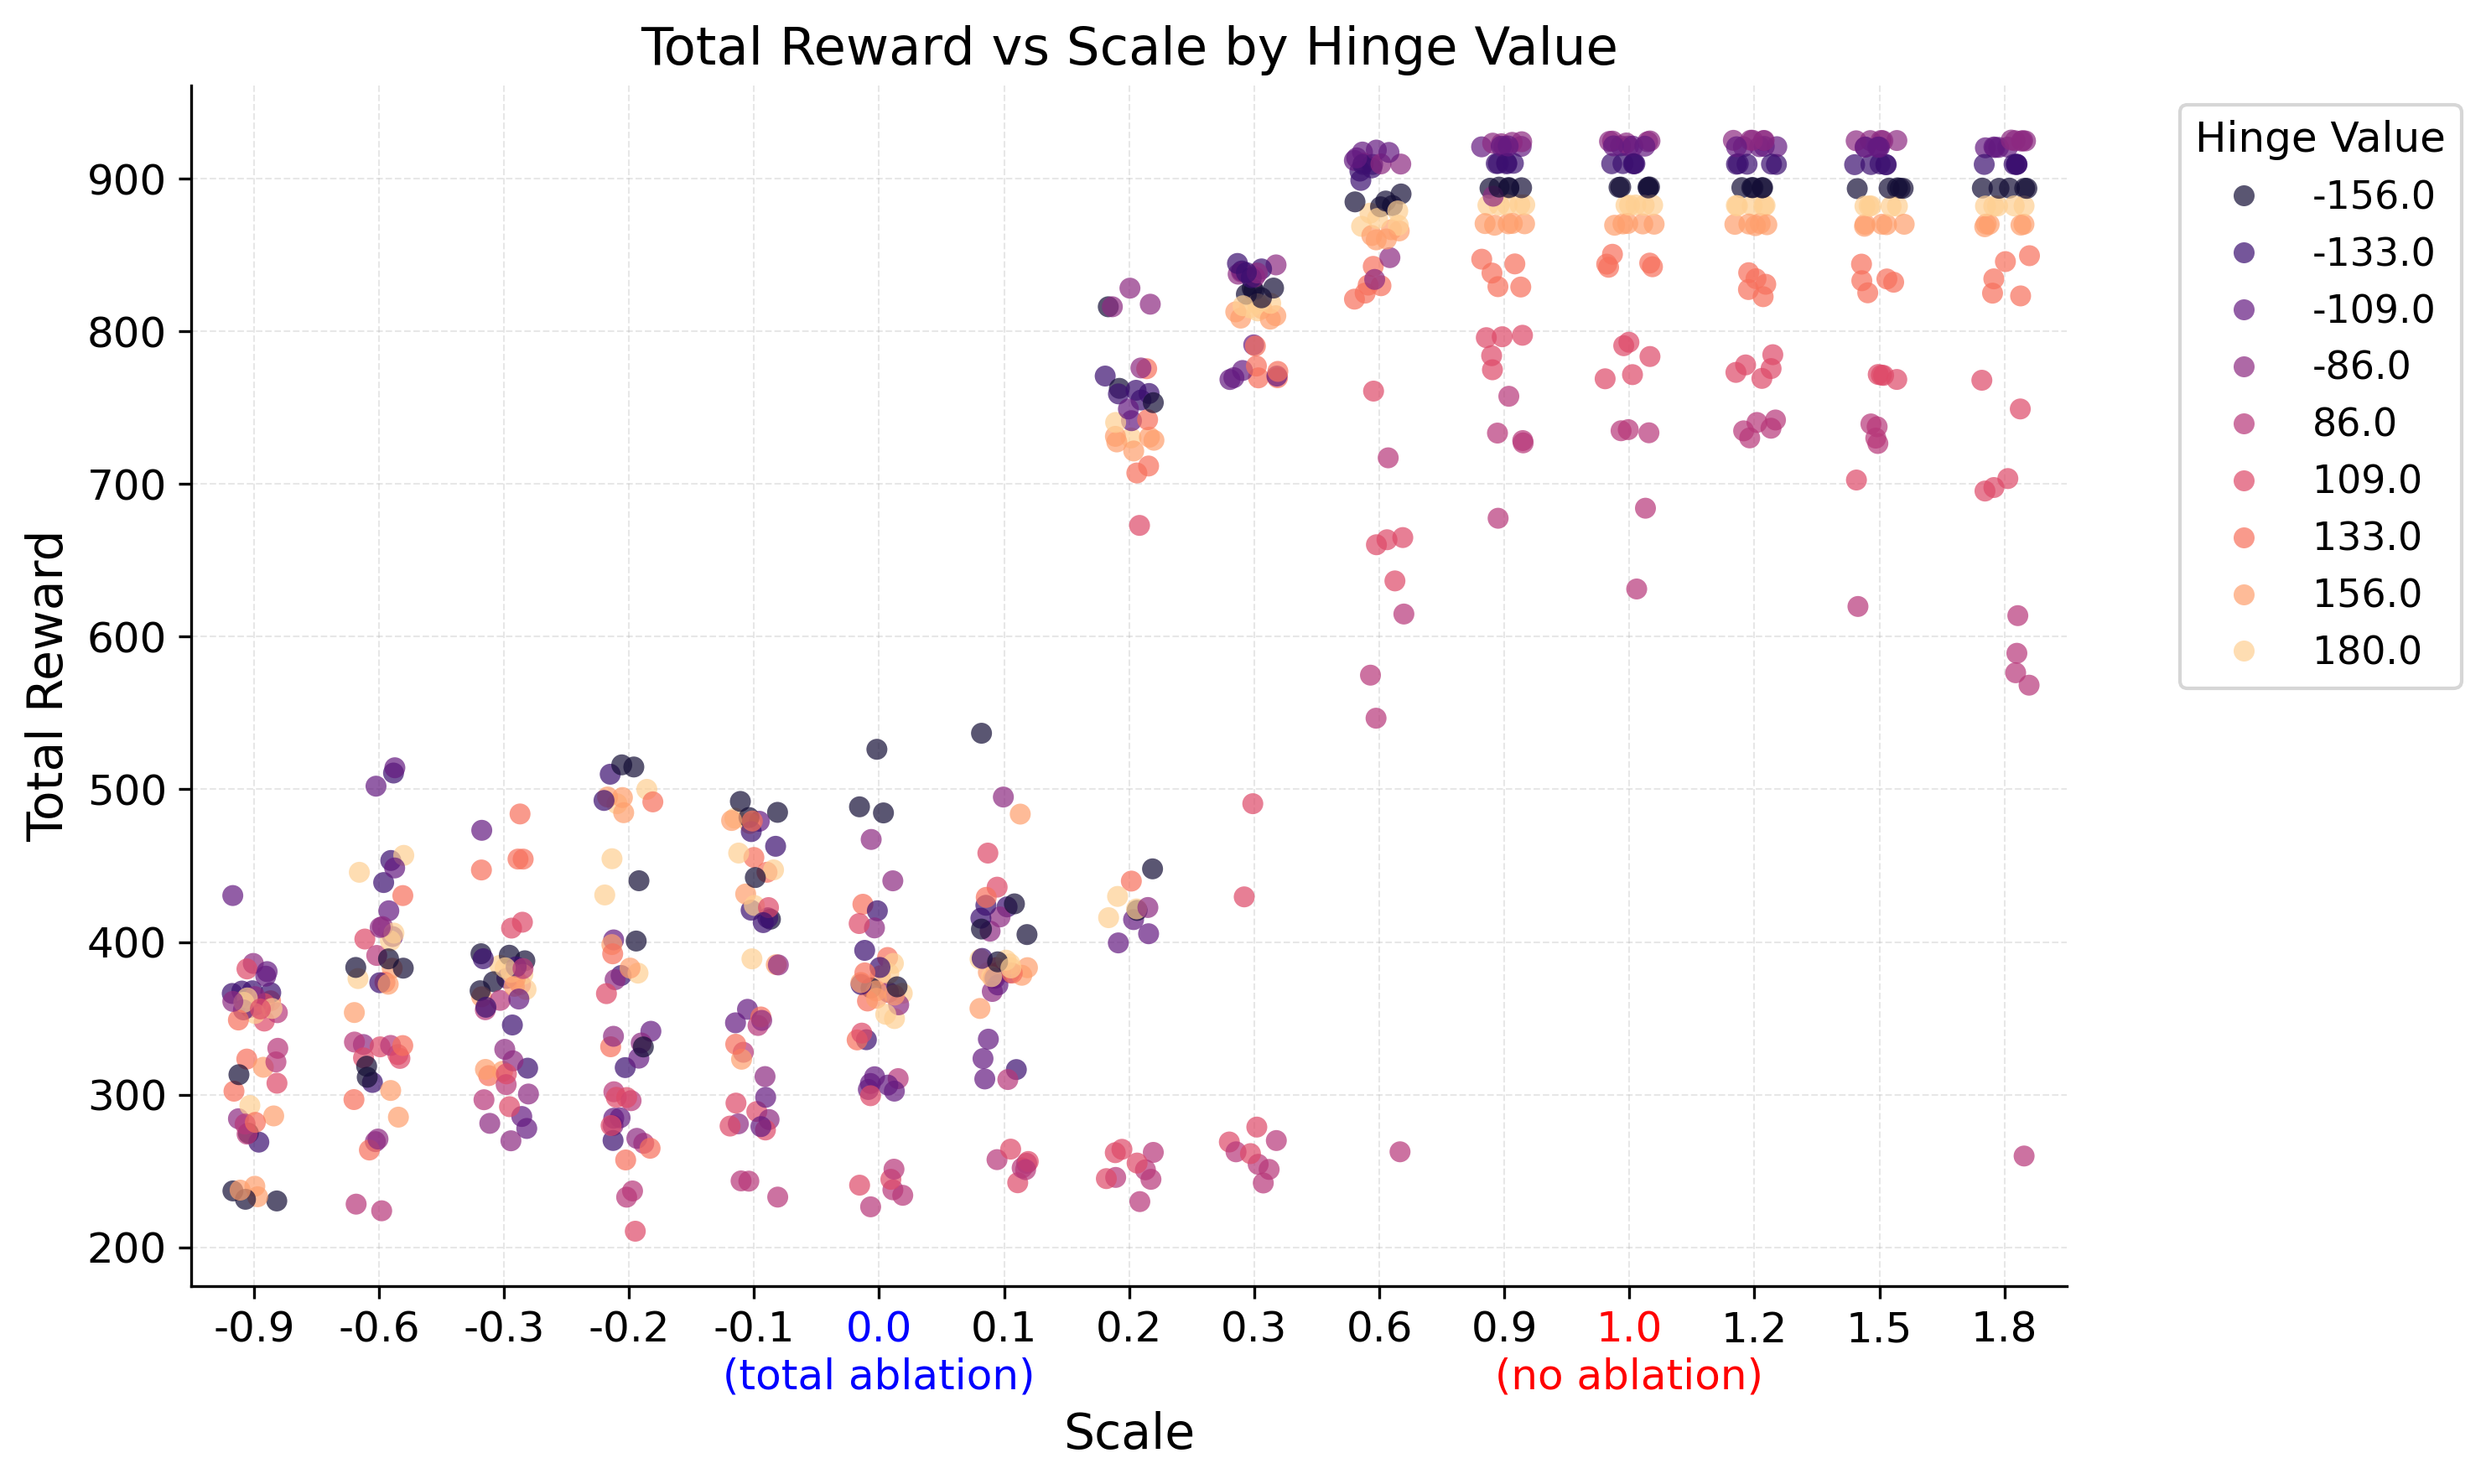

In [37]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

# Get unique hinge values and create color palette
hinge_order = sorted(df_pca_scale['hinge_str'].unique(), key=lambda x: float(x))
palette = sns.color_palette('tab10', n_colors=len(hinge_order))
color_map = {hinge: palette[i] for i, hinge in enumerate(hinge_order)}

# Create stripplot colored by hinge value
sns.stripplot(data=df_pca_scale,
              x='config_scale',
              y='total_reward',
              hue='hinge_str',
              hue_order=hinge_order,
              palette='magma',
              ax=ax,
              alpha=0.7,
              size=6,
              jitter=0.2)

ax.set_xlabel('Scale', fontsize=14)
ax.set_ylabel('Total Reward', fontsize=14)
ax.set_title('Total Reward vs Scale by Hinge Value', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.legend(title='Hinge Value',
          title_fontsize=12,
          fontsize=11,
          bbox_to_anchor=(1.05, 1),
          loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Color x-axis tick labels based on scale value
tick_labels = []
tick_colors = []
for label in ax.get_xticklabels():
    scale_value = float(label.get_text())
    if scale_value == 0.0:
        tick_labels.append(f'{scale_value}\n(total ablation)')
        tick_colors.append('blue')
    elif scale_value == 1.0:
        tick_labels.append(f'{scale_value}\n(no ablation)')
        tick_colors.append('red')
    else:
        tick_labels.append(f'{scale_value}')
        tick_colors.append('black')

# Set the new labels
ax.set_xticklabels(tick_labels)

# Apply colors to the labels
for label, color in zip(ax.get_xticklabels(), tick_colors):
    label.set_color(color)

#ax.set_ylim(-3, 103)
plt.tight_layout()
sns.despine()
plt.show()

In [38]:
df_pca_scale_data = load_intervention_data(
    df_metadata,
    intervention_type="directional_scaling_ablation",
    seed=None,
)
df_pca_scale_data = compute_success(df_pca_scale_data, consecutive_steps=100)

Found 675 configurations


100%|██████████| 675/675 [00:04<00:00, 151.17it/s]


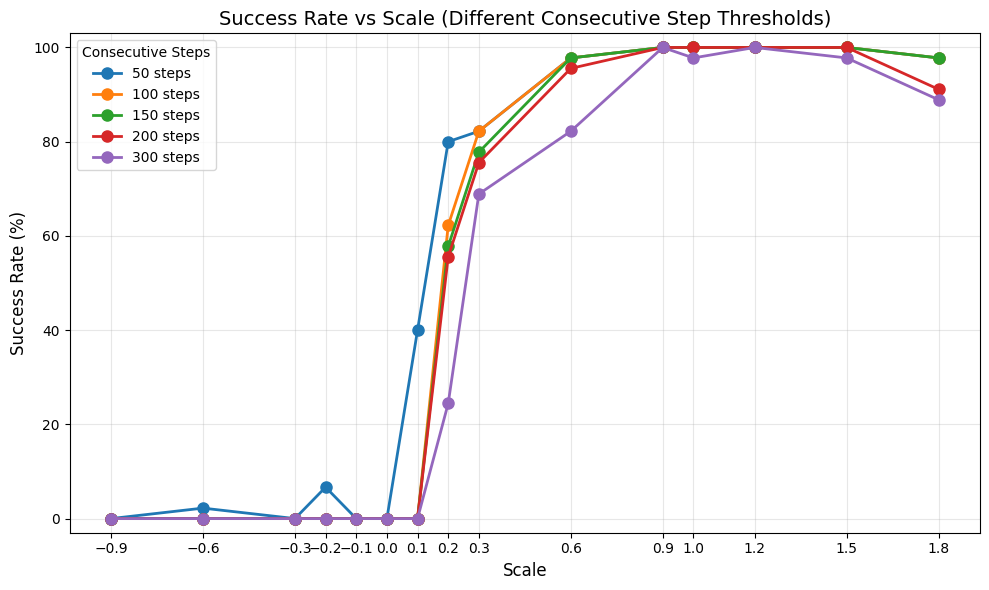

In [42]:
# Define different consecutive step thresholds to test
consecutive_steps_list = [50, 100, 150, 200, 300]

# Plot
plt.figure(figsize=(10, 6))

for consecutive_steps in consecutive_steps_list:
    # Compute success for this threshold
    df_temp = compute_success(df_pca_scale_data.copy(),
                              consecutive_steps=consecutive_steps)

    # Group by scale and compute mean success rate across seeds
    success_by_scale = df_temp.groupby(
        'config_scale')['success'].mean().reset_index()
    success_by_scale.columns = ['config_scale', 'success_rate']

    # Convert success rate to percentage
    success_by_scale[
        'success_percentage'] = success_by_scale['success_rate'] * 100

    # Plot line for this threshold
    plt.plot(success_by_scale['config_scale'],
             success_by_scale['success_percentage'],
             marker='o',
             linewidth=2,
             markersize=8,
             label=f'{consecutive_steps} steps')

plt.xlabel('Scale', fontsize=12)
plt.xticks(success_by_scale['config_scale'])
plt.ylabel('Success Rate (%)', fontsize=12)
plt.title('Success Rate vs Scale (Different Consecutive Step Thresholds)',
          fontsize=14)
plt.legend(title='Consecutive Steps', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-3, 103)
plt.show()

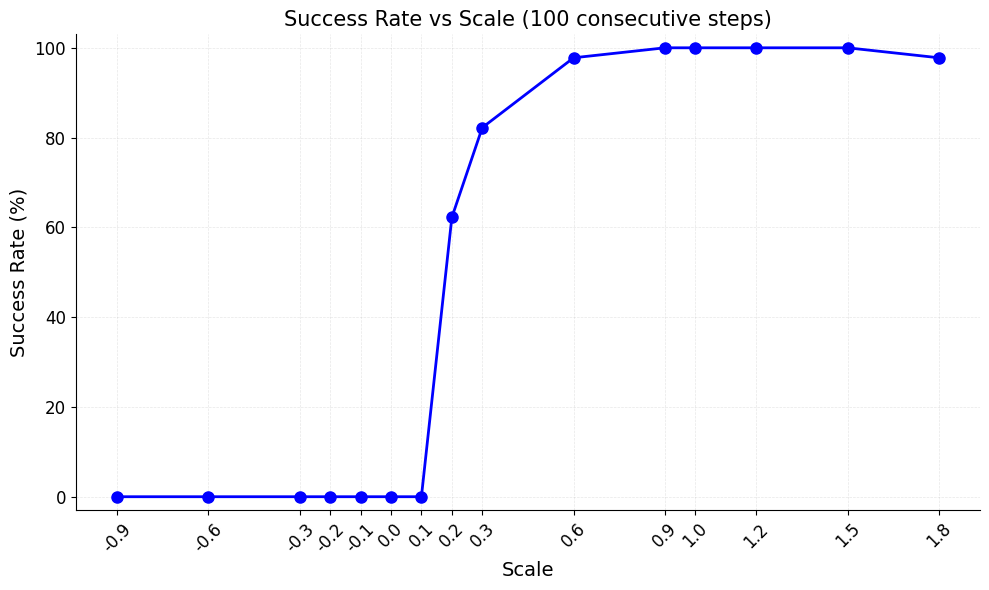

In [50]:
fig, ax = plt.subplots(figsize=(10, 6))

# Compute success for 100 consecutive steps
df_temp = compute_success(df_pca_scale_data.copy(), consecutive_steps=100)

# Group by scale, compute mean success rate across seeds AND hinge values
success_by_scale = df_temp.groupby(
    'config_scale')['success'].mean().reset_index()
success_by_scale.columns = ['config_scale', 'success_rate']

# Convert success rate to percentage
success_by_scale['success_percentage'] = success_by_scale['success_rate'] * 100

# Plot single line
ax.plot(success_by_scale['config_scale'],
        success_by_scale['success_percentage'],
        marker='o',
        linewidth=2,
        markersize=8,
        color='blue')

ax.set_xlabel('Scale', fontsize=14)
ax.set_ylabel('Success Rate (%)', fontsize=14)
ax.set_title('Success Rate vs Scale (100 consecutive steps)', fontsize=15)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Set x-axis ticks to be the config_scale values
ax.set_xticks(success_by_scale['config_scale'])
ax.set_xticklabels(success_by_scale['config_scale'], rotation=45)

ax.set_ylim(-3, 103)
plt.tight_layout()
sns.despine()
plt.show()

### sparsitfy directions

In [51]:
df_pca_sparse = df_metadata[df_metadata['config_type'] ==
                            'directional_ablation_sparse']

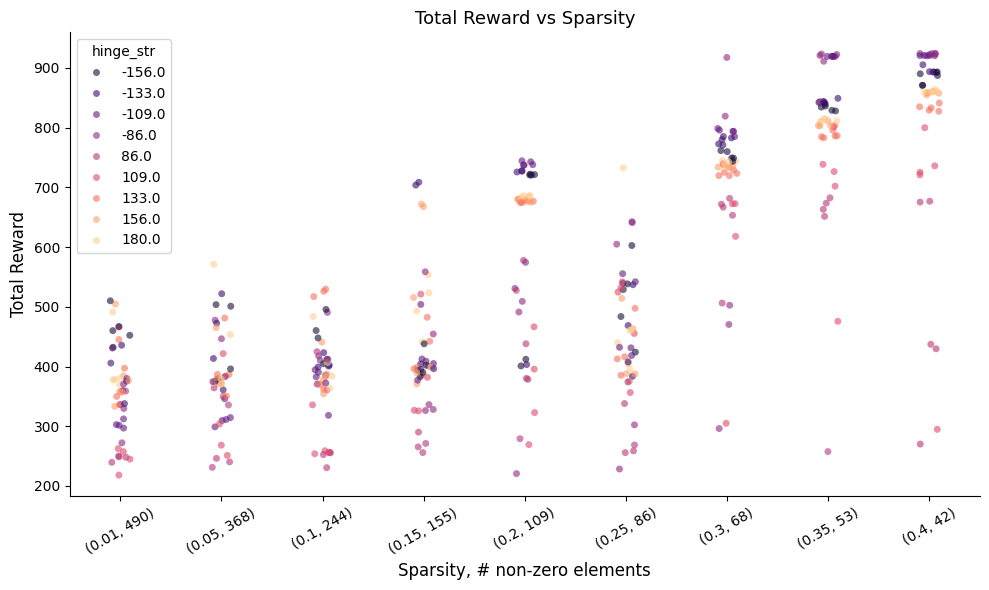

In [54]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ensure config_n_nonzero is not missing, else fill with a placeholder
df_temp = df_pca_sparse.copy()
if "config_n_nonzero" not in df_temp.columns:
    df_temp["config_n_nonzero"] = None

# Create tuple labels for xticks
xtick_labels = list(
    df_temp.drop_duplicates("config_eps_frac")[[
        "config_eps_frac", "config_n_nonzero"
    ]].sort_values("config_eps_frac").apply(
        lambda row: (row["config_eps_frac"], int(row["config_n_nonzero"])),
        axis=1))

sns.stripplot(
    data=df_temp,
    x='config_eps_frac',
    #x='config_cosine_similarity',
    y='total_reward',
    hue='hinge_str',
    ax=ax,
    alpha=0.6,
    hue_order=sorted(df_direction['hinge_str'].unique(),
                     key=lambda x: float(x)),
    palette='magma')

ax.set_xlabel('Sparsity, # non-zero elements', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Total Reward vs Sparsity', fontsize=13)

# Set xticks and tick labels as (eps_frac, n_nonzero)
ax.set_xticks(range(len(xtick_labels)))
ax.set_xticklabels(xtick_labels, rotation=30)
ax.tick_params(axis='x', labelsize=10)
sns.despine()
plt.tight_layout()
plt.show()

In [55]:
df_pca_sparse_data = load_intervention_data(
    df_metadata,
    intervention_type="directional_ablation_sparse",
    seed=None,
)
df_pca_sparse_data = compute_success(df_pca_sparse_data, consecutive_steps=100)

Found 405 configurations


100%|██████████| 405/405 [00:02<00:00, 148.09it/s]


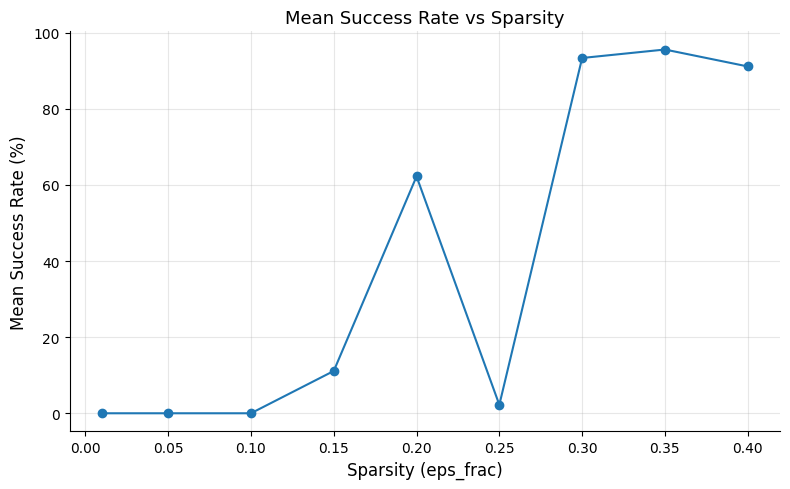

In [56]:
# Compute mean success for each sparsity (config_eps_frac)
mean_success_by_sparsity = (df_pca_sparse_data.groupby('config_eps_frac')
                            ['success'].mean().reset_index())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(mean_success_by_sparsity['config_eps_frac'],
        mean_success_by_sparsity['success'] * 100,
        marker='o',
        linestyle='-',
        color='C0')

ax.set_xlabel('Sparsity (eps_frac)', fontsize=12)
ax.set_ylabel('Mean Success Rate (%)', fontsize=12)
ax.set_title('Mean Success Rate vs Sparsity', fontsize=13)
ax.grid(True, alpha=0.3)
plt.tight_layout()
sns.despine()
plt.show()


## pca cumulative sufficiency

In [57]:
df_pca_cumulative_sufficiency = df_metadata[df_metadata['config_type'] ==
                                            'cumulative_pca_sufficiency']
df_pca_cumulative_sufficiency_data = load_intervention_data(
    df_metadata,
    intervention_type="cumulative_pca_sufficiency",
    seed=None,
)

Found 225 configurations


100%|██████████| 225/225 [00:01<00:00, 141.10it/s]


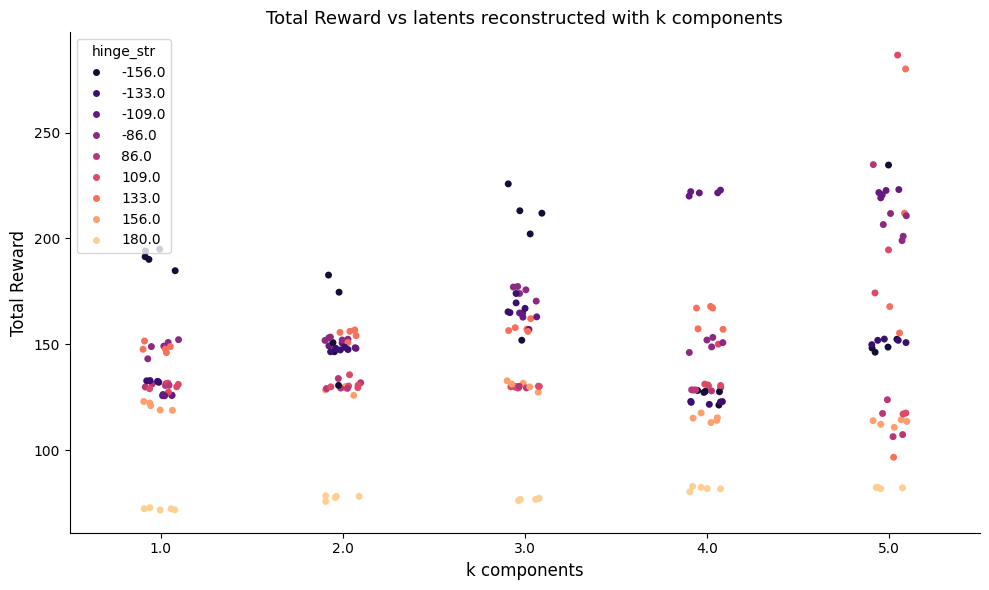

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.stripplot(data=df_pca_cumulative_sufficiency_data,
              x='config_k',
              y='total_reward',
              hue='hinge_str',
              ax=ax,
              alpha=1.0,
              hue_order=sorted(
                  df_pca_cumulative_sufficiency_data['hinge_str'].unique(),
                  key=lambda x: float(x)),
              palette='magma')

ax.set_xlabel('k components', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Total Reward vs latents reconstructed with k components',
             fontsize=13)

plt.tight_layout()
sns.despine()
plt.show()

## lasso analysis

In [7]:
df_lasso = df_metadata[df_metadata['config_type'] == 'lasso_ablation']
variables = df_lasso['config_variable'].unique()


In [8]:
df_lasso['num_selected_dims'] = df_lasso['config_selected_dims'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)

/scratch/slurm_tmpdir/job_1585912/ipykernel_3207672/3512524261.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_lasso['num_selected_dims'] = df_lasso['config_selected_dims'].apply(


In [12]:
# Define variable order and mapping to better names
variables_order = [
    'y_obs_cart_pos', 'y_obs_cospole_ang', 'y_obs_sinpole_ang',
    'y_obs_cart_vel', 'y_obs_pole_vel', 'reward', 'action', 'obs_all', 'all'
]

variable_name_mapping = {
    'y_obs_cart_pos': 'Cart Position',
    'y_obs_cospole_ang': 'Pole Angle (cos)',
    'y_obs_sinpole_ang': 'Pole Angle (sin)',
    'y_obs_cart_vel': 'Cart Velocity',
    'y_obs_pole_vel': 'Pole Velocity',
    'reward': 'Reward',
    'action': 'Action',
    'obs_all': 'All Observations',
    'all': 'All Variables'
}

# Order variables based on variables_order
variables = [
    v for v in variables_order if v in df_lasso['config_variable'].unique()
]

In [13]:
variables

['y_obs_cart_pos',
 'y_obs_cospole_ang',
 'y_obs_sinpole_ang',
 'y_obs_cart_vel',
 'y_obs_pole_vel',
 'reward',
 'action',
 'obs_all',
 'all']

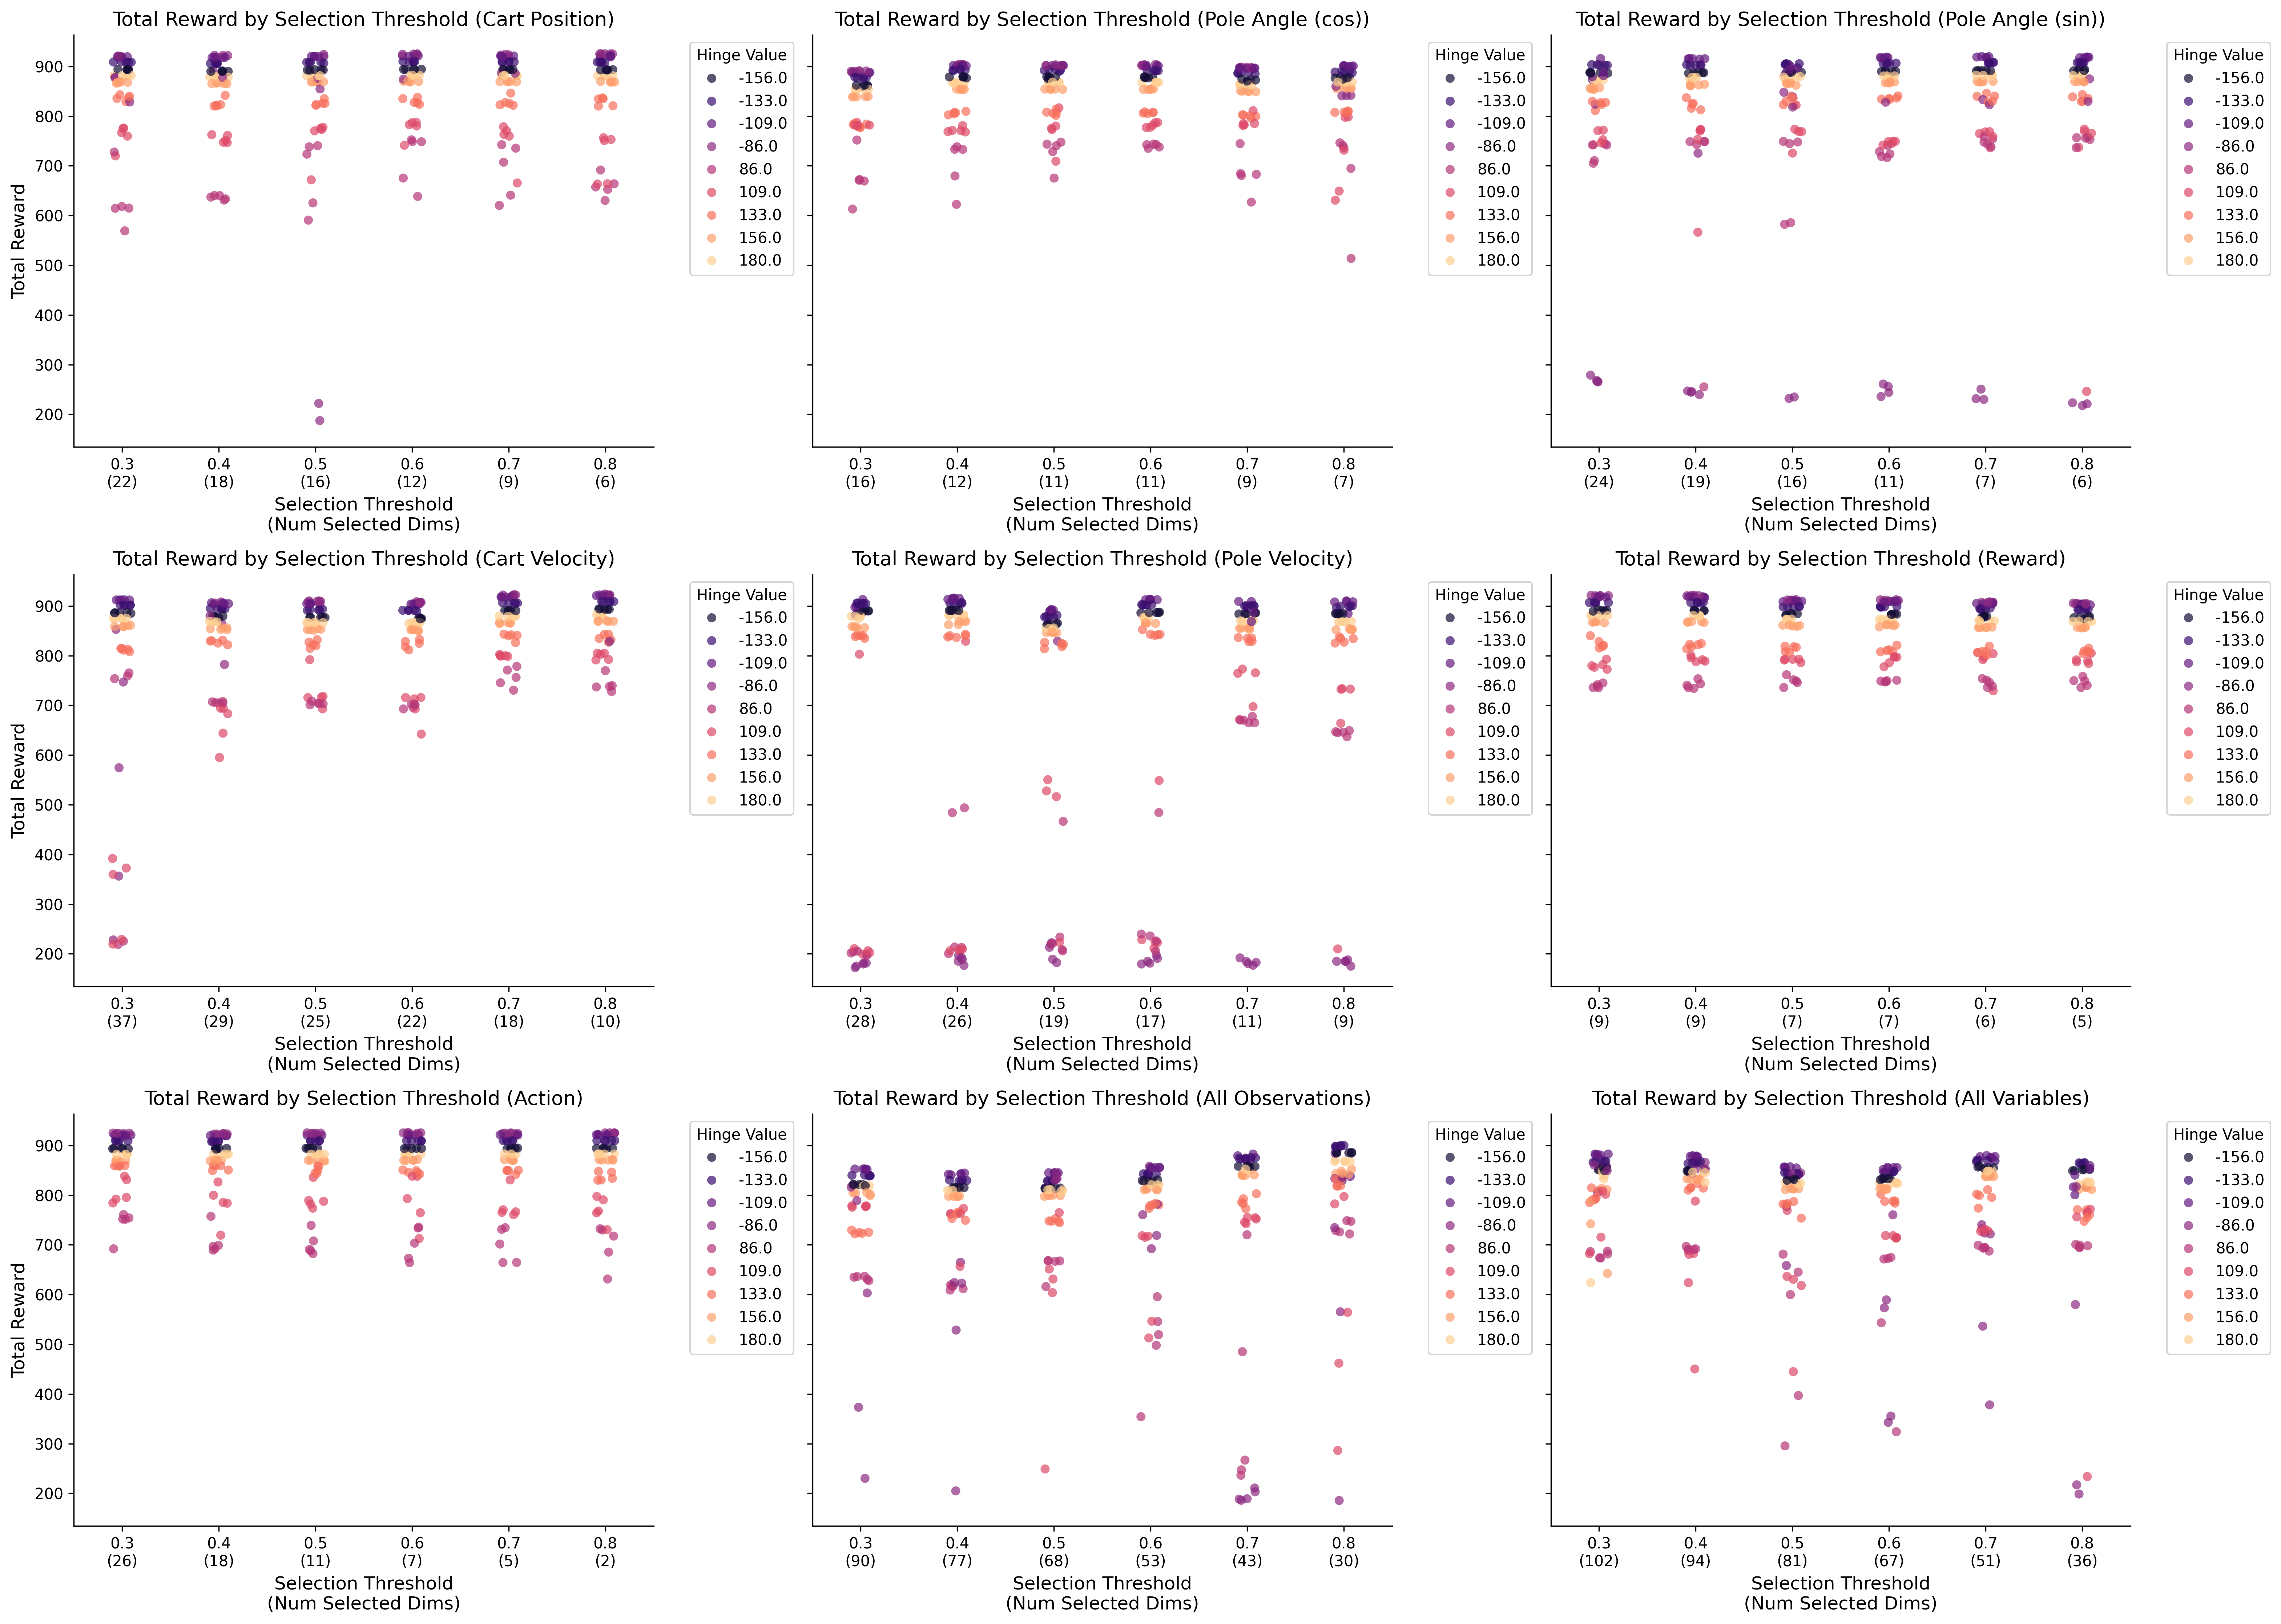

In [14]:
# Calculate number of rows needed (3 plots per row)
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

# Define consistent hinge order for all plots
hinge_order = sorted(df_lasso['hinge_str'].unique(), key=lambda x: float(x))

# Create figure with subplots
fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize=(21, 5 * n_rows),
                         sharey=True,
                         dpi=300)

# Flatten axes array for easier iteration
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot for each variable
for idx, variable in enumerate(variables):
    df_var = df_lasso[df_lasso['config_variable'] == variable]
    ax = axes_flat[idx]

    # Create stripplot with ordered hue
    sns.stripplot(data=df_var,
                  x='config_selection_threshold',
                  y='total_reward',
                  hue='hinge_str',
                  hue_order=hinge_order,
                  ax=ax,
                  alpha=0.7,
                  size=6,
                  palette='magma')

    # Get unique threshold values and their corresponding num_selected_dims
    threshold_dims = df_var.groupby(
        'config_selection_threshold')['num_selected_dims'].first().sort_index()

    # Create custom tick labels
    tick_labels = [
        f"{thresh}\n({dims})" for thresh, dims in threshold_dims.items()
    ]

    # Set custom tick labels
    ax.set_xticks(range(len(threshold_dims)))
    ax.set_xticklabels(tick_labels)

    ax.set_xlabel('Selection Threshold\n(Num Selected Dims)', fontsize=12)
    ax.set_ylabel('Total Reward', fontsize=12)
    ax.set_title(
        f'Total Reward by Selection Threshold ({variable_name_mapping[variable]})',
        fontsize=13)

    # Only show legend on first plot
    #if idx == 0:
    ax.legend(title='Hinge Value', bbox_to_anchor=(1.05, 1), loc='upper left')
    #else:
    #    ax.get_legend().remove()

# Hide any unused subplots
for idx in range(n_vars, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.tight_layout()
sns.despine()
plt.show()

In [16]:
df_lasso_data = load_intervention_data(
    df_metadata,
    intervention_type="lasso_ablation",
    #hinge_1_value=-1.5,
    seed=None,
    #pca_component_idx="1")
)


Found 2430 configurations


100%|██████████| 2430/2430 [00:42<00:00, 57.51it/s]


In [17]:
df_lasso_data = compute_success(df_lasso_data, consecutive_steps=100)

In [18]:
df_lasso_data['num_selected_dims'] = df_lasso_data[
    'config_selected_dims'].apply(lambda x: len(x)
                                  if isinstance(x, list) else 0)

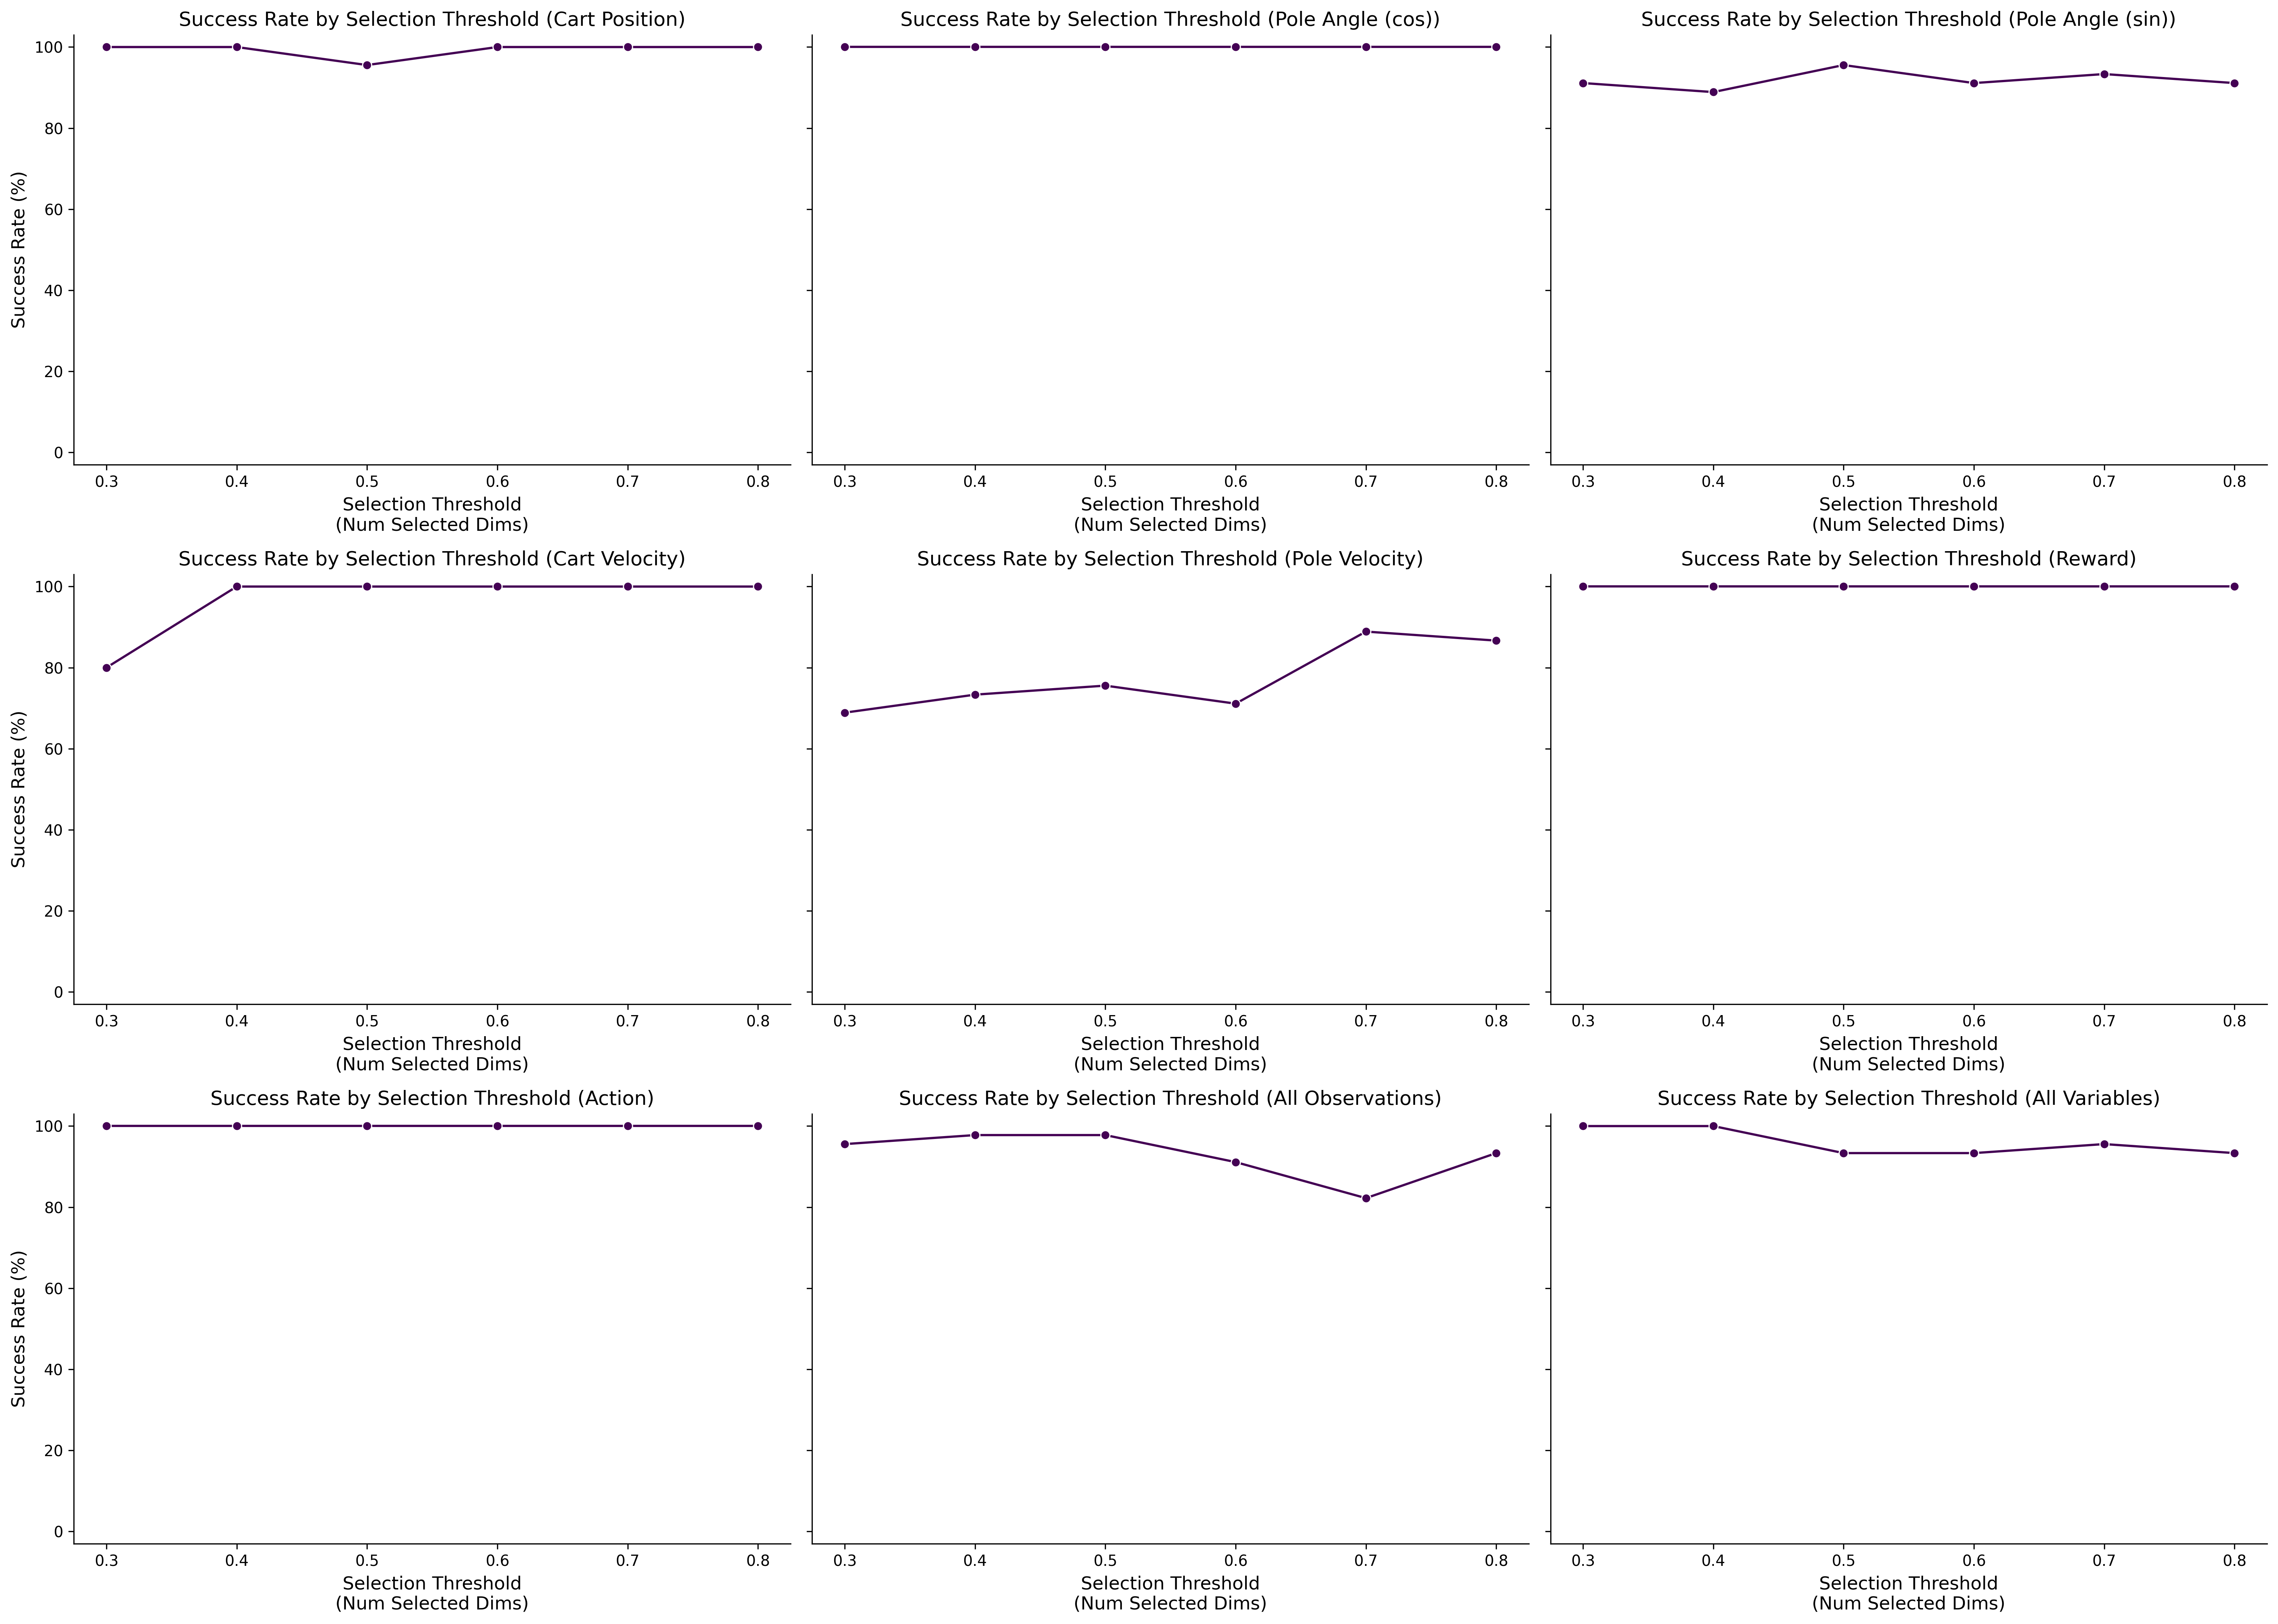

In [19]:
# Calculate number of rows needed (3 plots per row)
n_vars = len(variables)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols  # Ceiling division

# Create figure with subplots
fig, axes = plt.subplots(n_rows,
                         n_cols,
                         figsize=(21, 5 * n_rows),
                         sharey=True,
                         dpi=300)

# Flatten axes array for easier iteration
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot for each variable
for idx, variable in enumerate(variables):
    df_var = df_lasso_data[df_lasso_data['config_variable'] == variable]
    ax = axes_flat[idx]

    # Calculate mean success rate for each threshold (across all hinges)
    success_by_threshold = df_var.groupby(
        'config_selection_threshold')['success'].mean().reset_index()
    success_by_threshold[
        'success_percentage'] = success_by_threshold['success'] * 100

    # Create lineplot
    sns.lineplot(data=success_by_threshold,
                 x='config_selection_threshold',
                 y='success_percentage',
                 ax=ax,
                 marker='o',
                 markersize=6,
                 color='#440154')

    # Get unique threshold values and their corresponding num_selected_dims
    threshold_dims = df_var.groupby(
        'config_selection_threshold')['num_selected_dims'].first().sort_index()

    # # Create custom tick labels
    # tick_labels = [
    #     f"{thresh}\n({dims})" for thresh, dims in threshold_dims.items()
    # ]

    # # Set custom tick labels
    # ax.set_xticks(range(len(threshold_dims)))
    # ax.set_xticklabels(tick_labels)

    ax.set_xlabel('Selection Threshold\n(Num Selected Dims)', fontsize=12)
    ax.set_ylabel('Success Rate (%)', fontsize=12)
    ax.set_title(
        f'Success Rate by Selection Threshold ({variable_name_mapping[variable]})',
        fontsize=13)

# Hide any unused subplots
for idx in range(n_vars, len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.ylim(-3, 103)
plt.tight_layout()
sns.despine()
plt.show()

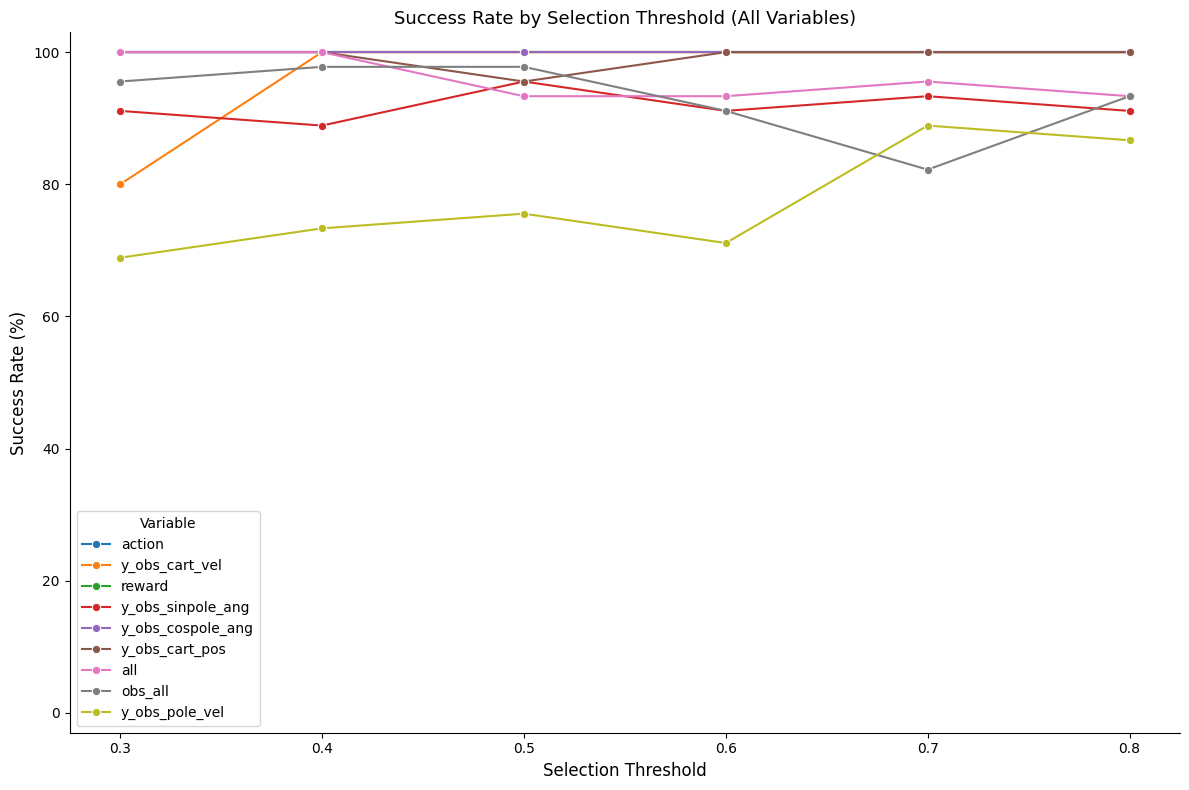

In [118]:
# Create single figure
fig, ax = plt.subplots(figsize=(12, 8))

# Plot for each variable
for idx, variable in enumerate(variables):
    df_var = df_lasso_data[df_lasso_data['config_variable'] == variable]

    # Calculate mean success rate for each threshold (across all hinges)
    success_by_threshold = df_var.groupby(
        'config_selection_threshold')['success'].mean().reset_index()
    success_by_threshold[
        'success_percentage'] = success_by_threshold['success'] * 100

    # Create lineplot
    sns.lineplot(data=success_by_threshold,
                 x='config_selection_threshold',
                 y='success_percentage',
                 ax=ax,
                 marker='o',
                 markersize=6,
                 label=variable)

ax.set_xlabel('Selection Threshold', fontsize=12)
ax.set_ylabel('Success Rate (%)', fontsize=12)
ax.set_title('Success Rate by Selection Threshold (All Variables)', fontsize=13)
ax.legend(title='Variable', fontsize=10)

plt.ylim(-3, 103)
plt.tight_layout()
sns.despine()
plt.show()

## plotting latents

In [158]:
idx = 4
latents = df_directional_ablation_data['latent_states'].iloc[idx].T
rewards = df_directional_ablation_data['rewards'].iloc[idx]
actions = df_directional_ablation_data['actions'].iloc[idx]

print(np.sum(rewards))
#print(np.sum(actions))


167.43169116709032


In [160]:
model, y, isort, X_embedding = fit_rastermap(latents,
                                             n_PCs=200,
                                             n_clusters=100,
                                             locality=0.75,
                                             time_lag_window=10)

2025-11-17 14:17:57,485 [INFO] normalizing data across axis=1
2025-11-17 14:17:57,488 [INFO] projecting out mean along axis=0
2025-11-17 14:17:57,490 [INFO] data normalized, 0.00sec
2025-11-17 14:17:57,491 [INFO] sorting activity: 512 valid samples by 500 timepoints
2025-11-17 14:17:57,531 [INFO] n_PCs = 200 computed, 0.05sec
2025-11-17 14:17:57,618 [INFO] 100 clusters computed, time 0.13sec
2025-11-17 14:18:53,879 [INFO] clusters sorted, time 56.39sec
2025-11-17 14:18:53,925 [INFO] clusters upsampled, time 56.44sec
2025-11-17 14:18:53,928 [INFO] rastermap complete, time 56.44sec


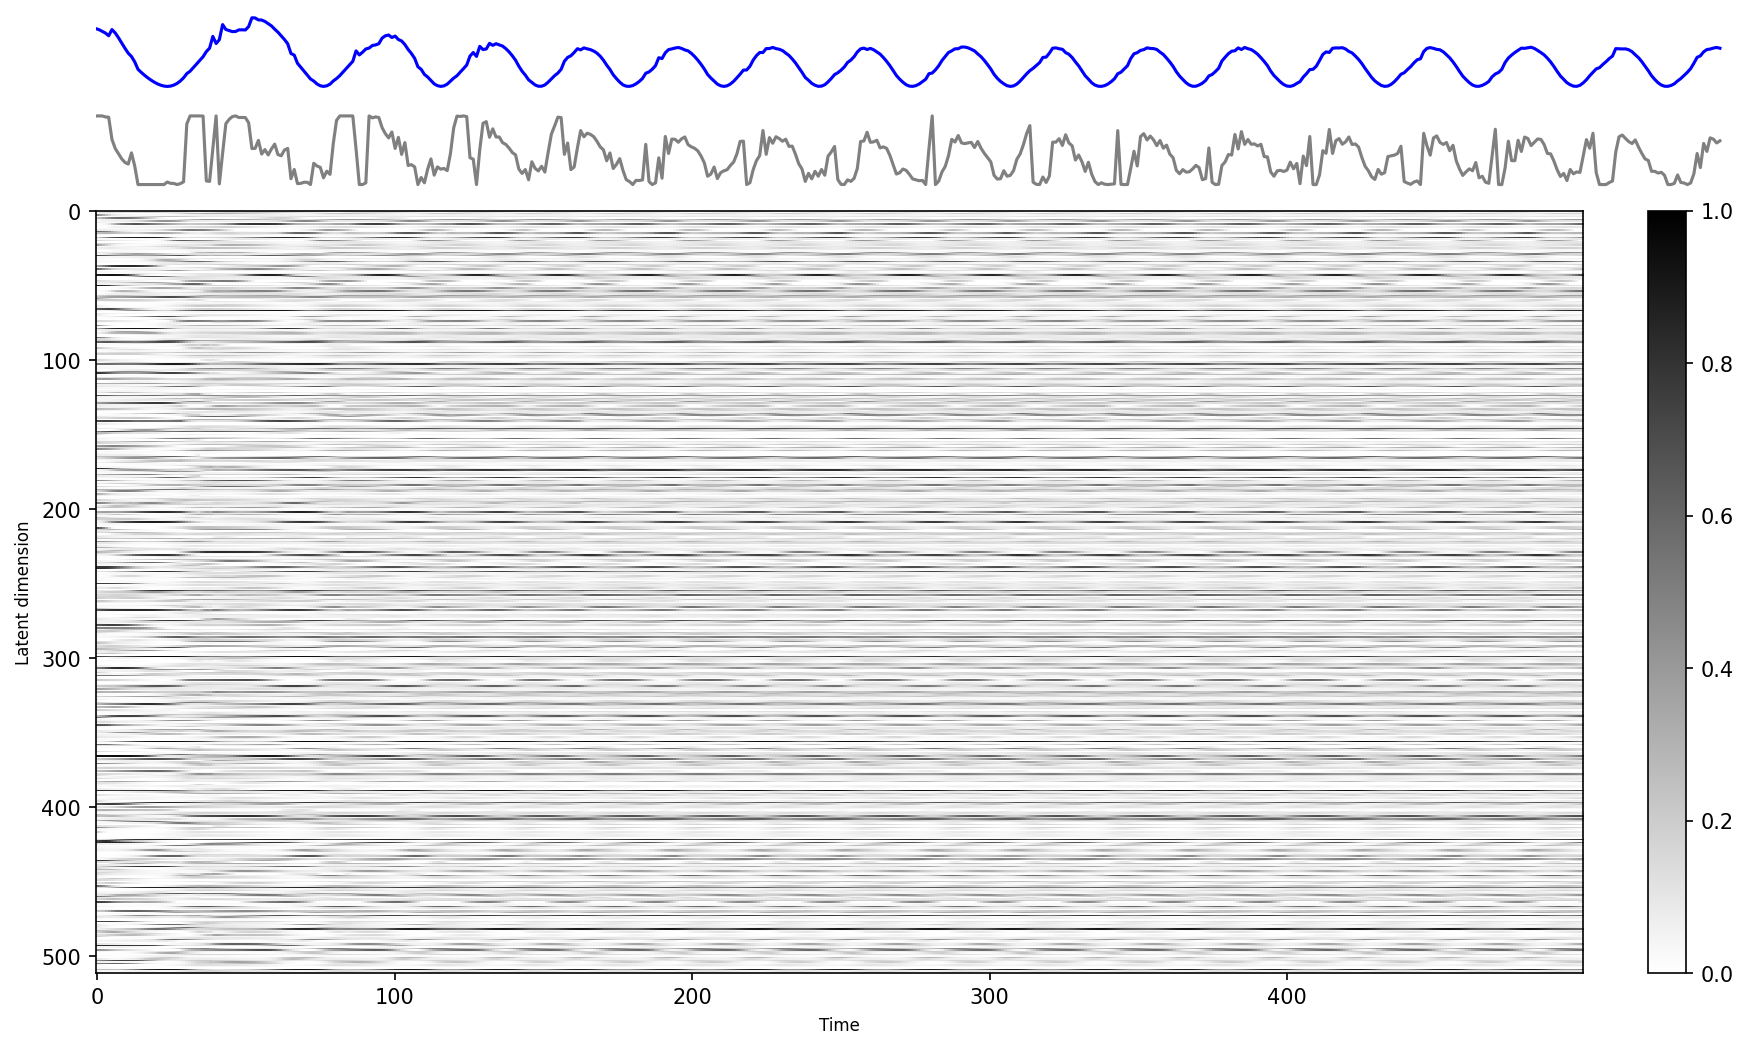

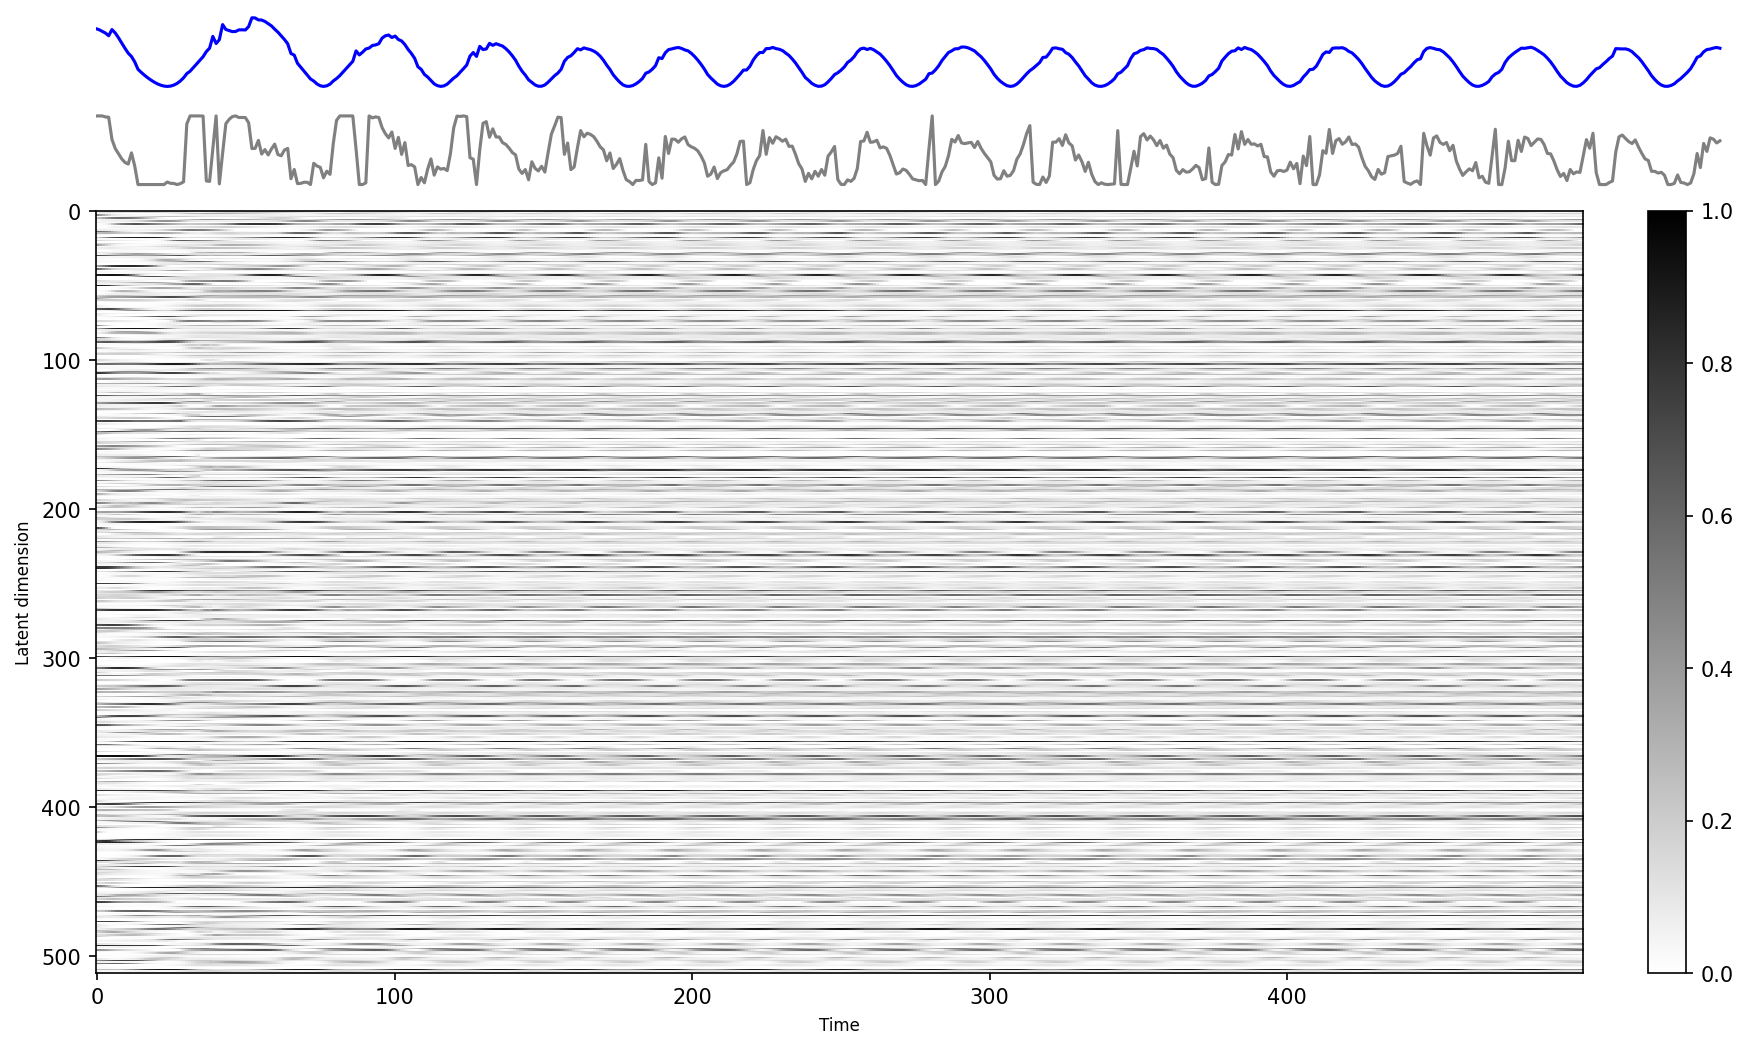

In [161]:
plot_rastermap_with_rewards_actions(rewards=rewards,
                                    actions=actions,
                                    latents=latents,
                                    plot_type='latents',
                                    sort_latents=False)
